In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt


# Linear Regression - Scikit-Learn vs From Scratch


In [2]:
# Load housing data (no header)
cols = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('housing.csv', sep=r'\s+', header=None, names=cols)
X = df[['RM']].values
y = df['MEDV'].values

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 404, Val: 51, Test: 51


In [3]:
# Scikit-Learn Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val)
y_test_pred_lr = lr_model.predict(X_test)

# Metrics
train_mse = mean_squared_error(y_train, y_train_pred_lr)
val_mse = mean_squared_error(y_val, y_val_pred_lr)
test_mse = mean_squared_error(y_test, y_test_pred_lr)
test_r2 = r2_score(y_test, y_test_pred_lr)

# Save for later
X_test_lr, y_test_lr, y_test_pred_lr_saved = X_test.copy(), y_test.copy(), y_test_pred_lr.copy()

print("\n=== Scikit-Learn Linear Regression ===")
print(f"Coefficients: w={lr_model.coef_[0]:.4f}, b={lr_model.intercept_:.4f}")
print(f"Train MSE: {train_mse:.4f}")
print(f"Val MSE: {val_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test R²: {test_r2:.4f}")



=== Scikit-Learn Linear Regression ===
Coefficients: w=9.3483, b=-36.2463
Train MSE: 42.9966
Val MSE: 58.9579
Test MSE: 33.3317
Test R²: 0.5982


# Logistic Regression - Scikit-Learn vs From Scratch


In [4]:
# Load Titanic data
df = pd.read_csv('train.csv')

# Preprocessing (matching v4)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Feature engineering (matching v4)
df['Pclass_squared'] = df['Pclass'] ** 2
df['Age_squared'] = df['Age'] ** 2
df['Fare_squared'] = df['Fare'] ** 2
df['Sex_Age'] = df['Sex'] * df['Age']
df['Pclass_Fare'] = df['Pclass'] * df['Fare']

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
            'Embarked_Q', 'Embarked_S',
            'Pclass_squared', 'Age_squared', 'Fare_squared',
            'Sex_Age', 'Pclass_Fare']

X = df[features].values
y = df['Survived'].values

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 623, Val: 134, Test: 134


In [5]:
# Scikit-Learn Logistic Regression (with L2 regularization)
log_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
log_model.fit(X_train, y_train)

# Predictions
y_train_pred = log_model.predict(X_train)
y_val_pred = log_model.predict(X_val)
y_test_pred = log_model.predict(X_test)

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\n=== Scikit-Learn Logistic Regression ===")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))



=== Scikit-Learn Logistic Regression ===
Train Accuracy: 0.8250
Val Accuracy: 0.8358
Test Accuracy: 0.7836

Confusion Matrix (Test):
[[72 15]
 [14 33]]


In [6]:
# Try different regularization strengths
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for C in C_values:
    model = LogisticRegression(penalty='l2', C=C, max_iter=1000, random_state=42, solver='lbfgs')
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    results.append({'C': C, 'train': train_acc, 'val': val_acc, 'test': test_acc})
    print(f"C={C:7.3f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

# Best model
best = max(results, key=lambda x: x['val'])
print(f"\nBest C={best['C']}: Val={best['val']:.4f}, Test={best['test']:.4f}")


C=  0.001 | Train: 0.7063 | Val: 0.6119 | Test: 0.7612
C=  0.010 | Train: 0.7994 | Val: 0.8134 | Test: 0.7537
C=  0.100 | Train: 0.8122 | Val: 0.8284 | Test: 0.7761
C=  1.000 | Train: 0.8250 | Val: 0.8358 | Test: 0.7836
C= 10.000 | Train: 0.8266 | Val: 0.8433 | Test: 0.7687
C=100.000 | Train: 0.8266 | Val: 0.8433 | Test: 0.7687

Best C=10.0: Val=0.8433, Test=0.7687


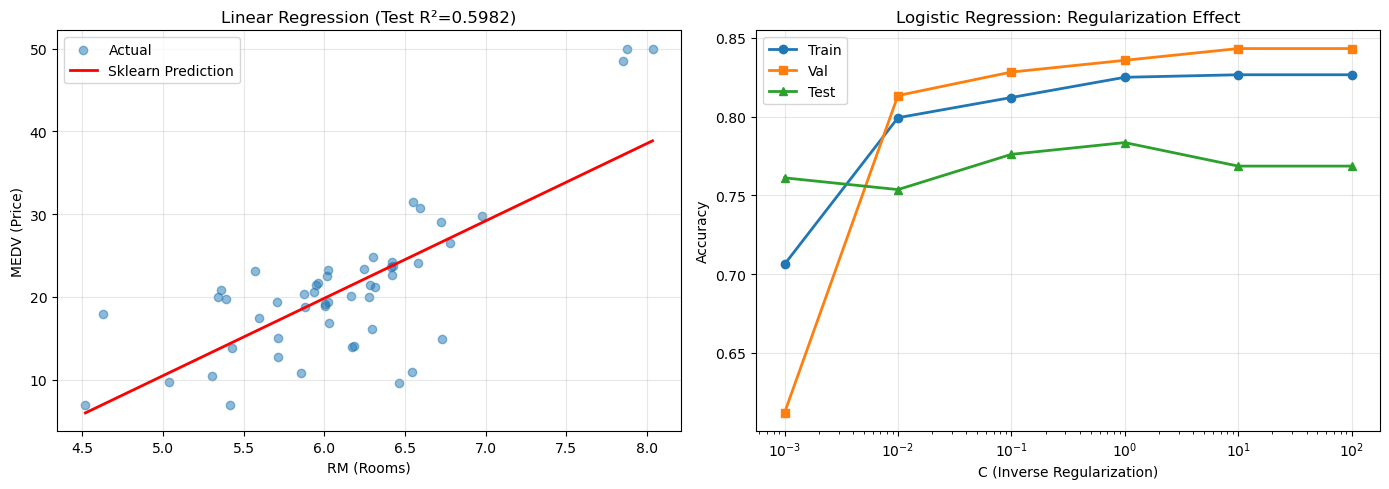


Comparison complete!


In [7]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression - sort for plotting
sort_idx = np.argsort(X_test_lr.flatten())
X_test_sorted = X_test_lr[sort_idx]
y_test_sorted = y_test_lr[sort_idx]
y_test_pred_sorted = y_test_pred_lr_saved[sort_idx]

axes[0].scatter(X_test_sorted, y_test_sorted, alpha=0.5, label='Actual')
axes[0].plot(X_test_sorted, y_test_pred_sorted, 'r-', linewidth=2, label='Sklearn Prediction')
axes[0].set_xlabel('RM (Rooms)')
axes[0].set_ylabel('MEDV (Price)')
axes[0].set_title(f'Linear Regression (Test R²={test_r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Logistic Regression - Regularization
C_vals = [r['C'] for r in results]
train_accs = [r['train'] for r in results]
val_accs = [r['val'] for r in results]
test_accs = [r['test'] for r in results]

axes[1].plot(C_vals, train_accs, 'o-', label='Train', linewidth=2)
axes[1].plot(C_vals, val_accs, 's-', label='Val', linewidth=2)
axes[1].plot(C_vals, test_accs, '^-', label='Test', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('C (Inverse Regularization)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Logistic Regression: Regularization Effect')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sklearn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nComparison complete!")
